   Unnamed: 0                Tweet  Followers  Friends  Num_tweets  Verified  \
0           0  1441497018807906305       1198    605.0        6166     False   
1           1  1431812786099613699        608   1259.0        1811     False   
2           2  1426644707313135617        173    167.0        4306     False   
3           3  1431814908425998337       2540    222.0        6008     False   
4           4  1432862687533441027       4439     11.0        9985     False   

   Listed_count Location  Age  Length  Num_users  Num_author_replies  \
0             1     True    7       6          4                   2   
1             5     True    2       2          2                   0   
2             0     True    0       4          2                   2   
3             0     True    9       2          2                   0   
4            55     True    2       4          3                   1   

   TOXICITY_x  Num_toxic_direct_replies  Num_toxic_nested_replies  \
0    0.235235    

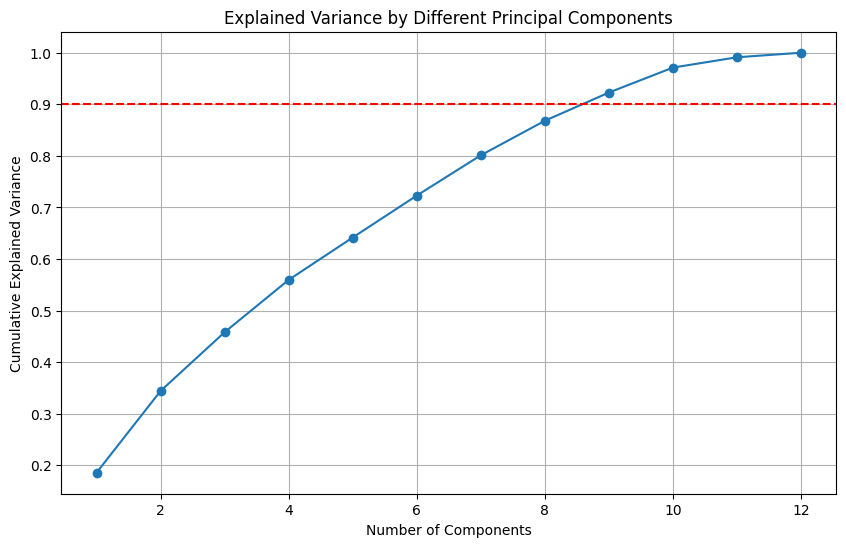


Number of components explaining ≥90% variance: 9

Cross-validation results:
Average Accuracy: 0.7359
Average F1 Score: 0.5187

Test set results:
Accuracy: 0.7396
F1 Score: 0.5194


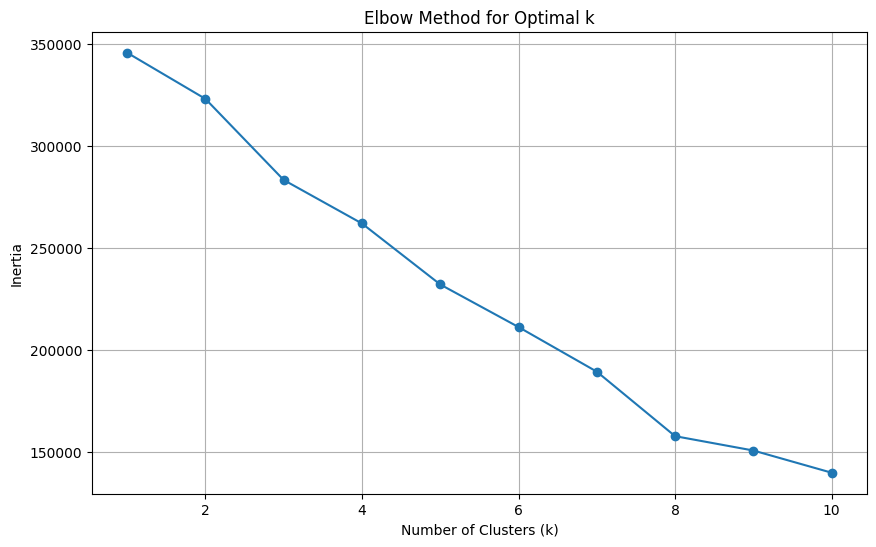


Selected number of clusters: 3

Cluster Centroids:
       Followers      Friends    Num_tweets      Verified  Listed_count  \
0    3456.574213   902.818864  13316.012602  1.907502e-14     15.980285   
1  557878.844898  6772.742177  85722.151020  9.585034e-01   2447.740816   
2    9423.588712  2283.916921  63671.999263 -1.734723e-15     71.551964   

   Location        Age     Length  Num_users  Num_author_replies  Toxicity  \
0  0.707292   1.685785   7.372690   4.537415            1.557970  0.213571   
1  0.861224  10.191837  39.484354  29.676871            0.955102  0.112957   
2  0.836580   9.419606   5.910603   4.064968            1.008845  0.172099   

   Num_author_toxic_replies  
0                  0.081326  
1                  0.013605  
2                  0.034748  

Cluster Analysis:

Cluster 0:
Size: 17865
Toxic conversation %: 25.45%
Characteristic features:
Followers     30241.946414
Num_tweets    20264.987269
Friends          754.57771
dtype: object

Cluster 1:
Size: 1470

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score

# 1. Load the dataset into a pandas DataFrame and inspect the first few rows
df = pd.read_csv('project_data.csv')
print(df.head())

# 2. Remove rows containing NaN values
df = df.dropna()
print("\nData shape after removing NaN values:", df.shape)

# 3. Create new variables
df['Total_toxic_replies'] = df['Num_toxic_direct_replies'] + df['Num_toxic_nested_replies']
df['Toxic_conversation'] = (df['Total_toxic_replies'] > 0).astype(int)

# Rename columns to match project instructions
df = df.rename(columns={'TOXICITY_x': 'Toxicity'})

# 4 & 5. Define features (X) and target (Y)
features = ['Followers', 'Friends', 'Num_tweets', 'Verified', 'Listed_count',
            'Location', 'Age', 'Length', 'Num_users', 'Num_author_replies',
            'Toxicity', 'Num_author_toxic_replies']
X = df[features]
y = df['Toxic_conversation']

# 6. Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 7. Principal components analysis
# Fit PCA and determine number of components
pca = PCA()
pca.fit(X_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.9, color='r', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by Different Principal Components')
plt.grid()
plt.show()

# Determine number of components that explain at least 90% of variance
n_components = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.9)[0][0] + 1
print(f"\nNumber of components explaining ≥90% variance: {n_components}")

# Transform the scaled features with selected components
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Visualize if 2 or 3 components
if n_components in [2, 3]:
    plt.figure(figsize=(8, 6))
    if n_components == 2:
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.5)
        plt.xlabel('Principal Component 1')
        plt.ylabel('Principal Component 2')
    else:
        ax = plt.axes(projection='3d')
        ax.scatter3D(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=y, alpha=0.5)
        ax.set_xlabel('Principal Component 1')
        ax.set_ylabel('Principal Component 2')
        ax.set_zlabel('Principal Component 3')
    plt.title('PCA Visualization')
    plt.colorbar(label='Toxic Conversation')
    plt.show()

# 8. Split the transformed dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# 9. Train logistic regression with 5-fold cross validation
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')  # Add class weighting
cv_accuracy = cross_val_score(logreg, X_train, y_train, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(logreg, X_train, y_train, cv=5, scoring='f1')

# 10. Report average F1 and accuracy across 5 folds
print("\nCross-validation results:")
print(f"Average Accuracy: {cv_accuracy.mean():.4f}")
print(f"Average F1 Score: {cv_f1.mean():.4f}")

# 11. Evaluate on testing dataset
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print("\nTest set results:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1 Score: {test_f1:.4f}")

# 12. K-means clustering
# Plot inertia for k values 1-10
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid()
plt.show()

# Determine optimal k using elbow method
optimal_k = 3  # Adjust based on my elbow plot
print(f"\nSelected number of clusters: {optimal_k}")

# Fit K-means with selected k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(X_scaled)
df['Cluster'] = kmeans.labels_

# Analyze cluster centroids
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
print("\nCluster Centroids:")
print(centroids)

# Add analysis of clusters
print("\nCluster Analysis:")
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    print(f"\nCluster {i}:")
    print(f"Size: {len(cluster_data)}")
    print(f"Toxic conversation %: {cluster_data['Toxic_conversation'].mean() * 100:.2f}%")
    print("Characteristic features:")
    # Find features most different from overall mean
    cluster_mean = cluster_data[features].mean()
    overall_mean = df[features].mean()
    diff = (cluster_mean - overall_mean).abs().sort_values(ascending=False)
    print(diff.head(3))

## PCA Component Selection (Markdown for #7.)

I went with **9 principal components** for this analysis because they explain over 90% of the total variance (based on the scree plot). It might seem like a lot to keep, but it helps maintain the model’s predictive strength.

Key considerations:
- The first few components didn’t capture enough variance—only around 60% with the first 5
- The scree plot showed a slow, steady drop instead of a sharp cutoff
- Keeping 90% of the variance helps make sure we’re not missing important patterns tied to toxicity
- In this case, the trade-off makes sense because we’d rather keep more information than risk losing key signals


Overall, my choice striked a good balance between reducing dimensionality and keeping the model accurate for predicting toxicity.

## Cluster Characteristics Analysis (Markdown for #12.)

Our K-Means clustering (k=3) revealed three distinct groups of Twitter conversations:

### Cluster 0: "Average Users" (62% of data)
- **Characteristics**: Mid-range follower counts (~3.5K) with fairly typical activity
- **Toxicity**: 25.45% of conversations were toxic
- **Key Features**: Most closely resembles the general Twitter user base
- **Interpretation**: This group acts as a baseline, showing normal toxicity levels from everyday interactions
### Cluster 1: "High-Profile Accounts" (5% of data)
- **Characteristics**: Huge followings (avg 557K), verified, extremely active
- **Toxicity**: 43.95% toxic conversations — the highest among the clusters
- **Key Features**: High visibility metrics — 2447 listed count, 85K tweets
- **Interpretation**: The high toxicity may be due to public attention and polarizing discussions around these users

### Cluster 2: "Low-Engagement Users" (33% of data)
- **Characteristics**: Low tweet counts and lower toxicity overall
- **Toxicity**: 21.22% toxic conversations — the lowest rate
- **Key Features**: Minimal activity across most metrics
- **Interpretation**: Likely more passive users or niche discussions with less friction